In [1]:
# ============================================================
# AutoWorth - AI Car Price Prediction Model
# Author: Lakshya Sahu
# ============================================================

# ## 0. Environment Setup

# Install libraries needed for dataset acquisition, analysis, and modeling.
# kagglehub -> downloads all four source datasets by their Kaggle handle
!pip install -q kagglehub pandas numpy scikit-learn seaborn matplotlib scipy


In [2]:
# Core imports used throughout the notebook
import os
import glob
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score, KFold, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Final feature contract expected by the AutoWorth AI Flask application.
# Order matters — this list is never reordered anywhere in the notebook.
FLASK_FEATURE_ORDER = [
    "Present_Price",
    "Kms_Driven",
    "Fuel_Type",
    "Seller_Type",
    "Transmission",
    "Owner",
    "Car_Age",
]
TARGET_COLUMN = "Selling_Price"

print("Environment ready. Target feature order for the Flask app:")
print(FLASK_FEATURE_ORDER)


Environment ready. Target feature order for the Flask app:
['Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'Car_Age']


In [3]:
# ## Step 1 — Dataset Download & Loading
#
# We pull all four source datasets automatically (no manual downloads), auto-detect
# every CSV file inside each download, load them, and profile them.

# ------------------------------------------------------------------
# 1a. Download all four source datasets with kagglehub (public datasets, no login needed)
# ------------------------------------------------------------------
import kagglehub

KAGGLEHUB_DATASETS = {
    "cardekho_vehicle_dataset": "nehalbirla/vehicle-dataset-from-cardekho",
    "bhavikjikadara_car_price": "bhavikjikadara/car-price-prediction-dataset",
    "taeefnajib_used_car_price": "taeefnajib/used-car-price-prediction-dataset",
    "harshghadiya_car_price": "harshghadiya/car-price-prediction",
}

kagglehub_paths = {}
for label, handle in KAGGLEHUB_DATASETS.items():
    path = kagglehub.dataset_download(handle)
    kagglehub_paths[label] = path
    print(f"{label:28s} -> {path}")

100%|██████████| 292k/292k [00:00<00:00, 70.6MB/s]

Extracting files...
cardekho_vehicle_dataset     -> /root/.cache/kagglehub/datasets/nehalbirla/vehicle-dataset-from-cardekho/versions/4


100%|██████████| 3.79k/3.79k [00:00<00:00, 1.88MB/s]

Extracting files...
bhavikjikadara_car_price     -> /root/.cache/kagglehub/datasets/bhavikjikadara/car-price-prediction-dataset/versions/1


100%|██████████| 109k/109k [00:00<00:00, 14.5MB/s]

Extracting files...
taeefnajib_used_car_price    -> /root/.cache/kagglehub/datasets/taeefnajib/used-car-price-prediction-dataset/versions/1


100%|██████████| 4.70k/4.70k [00:00<00:00, 7.68MB/s]

Extracting files...
harshghadiya_car_price       -> /root/.cache/kagglehub/datasets/harshghadiya/car-price-prediction/versions/2


In [4]:
# ------------------------------------------------------------------
# 1b. Auto-detect every CSV across all downloaded dataset folders
# ------------------------------------------------------------------
SEARCH_ROOTS = list(kagglehub_paths.values())

def find_all_csvs(roots):
    """Recursively find every .csv file under each root directory."""
    csv_paths = []
    for root in roots:
        csv_paths.extend(glob.glob(os.path.join(root, "**", "*.csv"), recursive=True))
    return sorted(set(csv_paths))

all_csv_paths = find_all_csvs(SEARCH_ROOTS)

print(f"Discovered {len(all_csv_paths)} CSV file(s):")
for p in all_csv_paths:
    print(" -", p)


Discovered 7 CSV file(s):
 - /root/.cache/kagglehub/datasets/bhavikjikadara/car-price-prediction-dataset/versions/1/car_prediction_data.csv
 - /root/.cache/kagglehub/datasets/harshghadiya/car-price-prediction/versions/2/carprice.csv
 - /root/.cache/kagglehub/datasets/nehalbirla/vehicle-dataset-from-cardekho/versions/4/CAR DETAILS FROM CAR DEKHO.csv
 - /root/.cache/kagglehub/datasets/nehalbirla/vehicle-dataset-from-cardekho/versions/4/Car details v3.csv
 - /root/.cache/kagglehub/datasets/nehalbirla/vehicle-dataset-from-cardekho/versions/4/car data.csv
 - /root/.cache/kagglehub/datasets/nehalbirla/vehicle-dataset-from-cardekho/versions/4/car details v4.csv
 - /root/.cache/kagglehub/datasets/taeefnajib/used-car-price-prediction-dataset/versions/1/used_cars.csv


In [5]:
# ------------------------------------------------------------------
# 1c. Load every discovered CSV into a dictionary of DataFrames
# ------------------------------------------------------------------
raw_datasets = {}

for path in all_csv_paths:
    name = os.path.splitext(os.path.basename(path))[0]
    try:
        df = pd.read_csv(path)
    except UnicodeDecodeError:
        df = pd.read_csv(path, encoding="latin-1")
    # Skip trivially empty or non-tabular files (e.g. stray metadata CSVs)
    if df.shape[0] == 0 or df.shape[1] < 3:
        print(f"Skipping '{name}' — not a usable tabular dataset ({df.shape}).")
        continue
    # De-duplicate names if two files share a basename
    key = name
    suffix = 1
    while key in raw_datasets:
        key = f"{name}_{suffix}"
        suffix += 1
    raw_datasets[key] = df

print(f"Loaded {len(raw_datasets)} dataset(s): {list(raw_datasets.keys())}")


Loaded 7 dataset(s): ['car_prediction_data', 'carprice', 'CAR DETAILS FROM CAR DEKHO', 'Car details v3', 'car data', 'car details v4', 'used_cars']


In [6]:
# ------------------------------------------------------------------
# 1d. Profile every loaded dataset
# ------------------------------------------------------------------
def guess_target_column(df):
    """Heuristically guess which column represents the sale/listing price."""
    candidates = ["selling_price", "sellingprice", "price", "sale_price", "saleprice"]
    for col in df.columns:
        if col.strip().lower().replace(" ", "_") in candidates:
            return col
    return "Not identified"

def profile_dataset(name, df):
    print("=" * 90)
    print(f"Dataset: {name}")
    print("=" * 90)
    print(f"Rows                : {df.shape[0]}")
    print(f"Columns             : {df.shape[1]}")
    print(f"Duplicate rows      : {df.duplicated().sum()}")
    print(f"Memory usage        : {df.memory_usage(deep=True).sum() / 1024**2:.3f} MB")
    print(f"Likely target column: {guess_target_column(df)}")
    print("\nColumn names & dtypes:")
    print(df.dtypes)
    print("\nMissing values per column:")
    missing = df.isna().sum()
    print(missing[missing > 0] if missing.sum() > 0 else "None")
    print()

for name, df in raw_datasets.items():
    profile_dataset(name, df)


Dataset: car_prediction_data
Rows                : 301
Columns             : 9
Duplicate rows      : 2
Memory usage        : 0.076 MB
Likely target column: Selling_Price

Column names & dtypes:
Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type         object
Seller_Type       object
Transmission      object
Owner              int64
dtype: object

Missing values per column:
None

Dataset: carprice
Rows                : 199
Columns             : 26
Duplicate rows      : 0
Memory usage        : 0.142 MB
Likely target column: price

Column names & dtypes:
symboling              int64
normalized-losses     object
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height   

In [7]:
# ## Step 2 — Dataset Comparison & Column Mapping
#
# Rather than guessing which column in each dataset corresponds to which required
# feature, we compare every raw column name against a hand-built alias dictionary
# for each field the Flask application needs. A dataset is only treated as
# **compatible** if it exposes (directly or via a clear alias) every field required
# to build the model's feature set. Datasets that don't are explained and excluded
# — they are never force-merged.

# ------------------------------------------------------------------
# 2a. Canonical schema + alias dictionary
#
# Keys   = canonical column name used from this point forward in the pipeline
# Values = every raw column-name spelling we are willing to recognise as that field
# ------------------------------------------------------------------
COLUMN_ALIASES = {
    "Car_Name":      ["car_name", "name", "carname", "model", "car_model"],
    "Year":          ["year", "model_year", "manufacture_year", "yr"],
    "Selling_Price": ["selling_price", "sellingprice", "price", "sale_price", "saleprice"],
    "Present_Price": ["present_price", "presentprice", "ex_showroom_price", "showroom_price"],
    "Kms_Driven":    ["kms_driven", "km_driven", "kilometers_driven", "mileage_km", "kms"],
    "Fuel_Type":     ["fuel_type", "fueltype", "fuel"],
    "Seller_Type":   ["seller_type", "sellertype", "seller"],
    "Transmission":  ["transmission", "gear_type", "gearbox"],
    "Owner":         ["owner", "owner_type", "previous_owners", "no_of_owners"],
}

# Fields that MUST be present (directly or via alias) for a dataset to be usable
# by the Flask application's feature contract. "Year" is required because
# Car_Age (a required Flask feature) is derived from it.
REQUIRED_CANONICAL_FIELDS = [
    "Present_Price", "Kms_Driven", "Fuel_Type",
    "Seller_Type", "Transmission", "Owner", "Selling_Price", "Year",
]

def normalize_col(col):
    return col.strip().lower().replace(" ", "_").replace("-", "_")

def match_columns_to_schema(df):
    """
    Returns a dict: canonical_name -> actual_column_name_in_df (or None if absent).
    Never guesses beyond the explicit alias list above.
    """
    normalized_lookup = {normalize_col(c): c for c in df.columns}
    mapping = {}
    for canonical, aliases in COLUMN_ALIASES.items():
        found = None
        for alias in aliases:
            if alias in normalized_lookup:
                found = normalized_lookup[alias]
                break
        mapping[canonical] = found
    return mapping

schema_matches = {name: match_columns_to_schema(df) for name, df in raw_datasets.items()}

comparison_rows = []
for name, mapping in schema_matches.items():
    row = {"dataset": name}
    row.update({k: (v if v else "—") for k, v in mapping.items()})
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows).set_index("dataset")
comparison_df


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
dataset,,,,,,,,,
car_prediction_data,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
carprice,—,—,price,—,—,fuel-type,—,—,—
CAR DETAILS FROM CAR DEKHO,name,year,selling_price,—,km_driven,fuel,seller_type,transmission,owner
Car details v3,name,year,selling_price,—,km_driven,fuel,seller_type,transmission,owner
car data,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
car details v4,Model,Year,Price,—,—,Fuel Type,Seller Type,Transmission,Owner
used_cars,model,model_year,price,—,—,fuel_type,—,transmission,—


In [8]:
# ------------------------------------------------------------------
# 2b. Decide which datasets are compatible with the required feature set
# ------------------------------------------------------------------
compatible_datasets = {}
excluded_datasets = {}

for name, mapping in schema_matches.items():
    missing_fields = [f for f in REQUIRED_CANONICAL_FIELDS if mapping.get(f) is None]
    if missing_fields:
        excluded_datasets[name] = missing_fields
    else:
        compatible_datasets[name] = mapping

print("COMPATIBLE datasets (will be merged):")
for name in compatible_datasets:
    print(f"  - {name}")

print("\nEXCLUDED datasets (schema does not support the required features):")
for name, missing in excluded_datasets.items():
    print(f"  - {name}: missing {missing}")

if not compatible_datasets:
    raise RuntimeError(
        "No downloaded dataset satisfies the required feature schema. "
        "Cannot proceed to merging."
    )


COMPATIBLE datasets (will be merged):
  - car_prediction_data
  - car data

EXCLUDED datasets (schema does not support the required features):
  - carprice: missing ['Present_Price', 'Kms_Driven', 'Seller_Type', 'Transmission', 'Owner', 'Year']
  - CAR DETAILS FROM CAR DEKHO: missing ['Present_Price']
  - Car details v3: missing ['Present_Price']
  - car details v4: missing ['Present_Price', 'Kms_Driven']
  - used_cars: missing ['Present_Price', 'Kms_Driven', 'Seller_Type', 'Owner']


In [9]:
# ## Step 3 — Data Cleaning
#
# Each compatible dataset is cleaned conservatively: duplicates removed, missing
# values handled, text trimmed and capitalization fixed, dtypes corrected, and
# impossible values (negative prices/kms, future years, unknown categories)
# dropped.

CURRENT_YEAR = pd.Timestamp.now().year

def clean_dataset(df, mapping):
    """
    Renames columns to canonical names using `mapping`, then applies
    conservative cleaning. Returns a cleaned DataFrame with ONLY the
    canonical columns that were actually found.
    """
    keep = {v: k for k, v in mapping.items() if v is not None}
    clean = df[list(keep.keys())].rename(columns=keep).copy()

    # Remove exact duplicate rows (duplicate vehicle listings)
    clean = clean.drop_duplicates()

    # Trim whitespace and fix capitalization on text columns
    text_cols = clean.select_dtypes(include="object").columns
    for col in text_cols:
        clean[col] = clean[col].astype(str).str.strip().str.title()

    # Coerce numeric columns, dropping rows that fail to convert
    numeric_cols = ["Year", "Selling_Price", "Present_Price", "Kms_Driven", "Owner"]
    for col in numeric_cols:
        if col in clean.columns:
            clean[col] = pd.to_numeric(clean[col], errors="coerce")

    # Drop rows missing any of the required fields — conservative, no imputation
    # of core numeric fields since guessing a car's price/kms would bias the model
    required_present = [c for c in REQUIRED_CANONICAL_FIELDS if c in clean.columns]
    clean = clean.dropna(subset=required_present)

    # Remove impossible values
    if "Selling_Price" in clean:
        clean = clean[clean["Selling_Price"] > 0]
    if "Present_Price" in clean:
        clean = clean[clean["Present_Price"] > 0]
    if "Kms_Driven" in clean:
        clean = clean[clean["Kms_Driven"] >= 0]
    if "Year" in clean:
        clean = clean[(clean["Year"] >= 1980) & (clean["Year"] <= CURRENT_YEAR)]
    if "Owner" in clean:
        clean = clean[clean["Owner"] >= 0]

    clean = clean.reset_index(drop=True)
    return clean

cleaned_datasets = {}
for name, mapping in compatible_datasets.items():
    before = raw_datasets[name].shape[0]
    cleaned = clean_dataset(raw_datasets[name], mapping)
    after = cleaned.shape[0]
    cleaned_datasets[name] = cleaned
    print(f"{name:35s} rows {before:>6d} -> {after:>6d}  (dropped {before - after})")


car_prediction_data                 rows    301 ->    299  (dropped 2)
car data                            rows    301 ->    299  (dropped 2)


In [10]:
# ## Step 4 — Data Standardization
#
# Categorical values differ in spelling/case across sources (e.g. `"petrol"` vs
# `"Petrol"` vs `"PETROL"`). We standardize every categorical field to one
# consistent vocabulary before merging, and standardize numeric columns' dtypes
# too.

FUEL_TYPE_MAP = {
    "petrol": "Petrol", "gasoline": "Petrol", "gas": "Petrol",
    "diesel": "Diesel",
    "cng": "CNG",
    "lpg": "LPG",
    "electric": "Electric", "ev": "Electric",
}

TRANSMISSION_MAP = {
    "manual": "Manual",
    "automatic": "Automatic", "auto": "Automatic",
}

SELLER_TYPE_MAP = {
    "dealer": "Dealer",
    "individual": "Individual",
    "trustmark dealer": "Dealer",
}

def standardize_dataset(df):
    df = df.copy()

    if "Fuel_Type" in df:
        df["Fuel_Type"] = (
            df["Fuel_Type"].astype(str).str.strip().str.lower().map(FUEL_TYPE_MAP)
        )
    if "Transmission" in df:
        df["Transmission"] = (
            df["Transmission"].astype(str).str.strip().str.lower().map(TRANSMISSION_MAP)
        )
    if "Seller_Type" in df:
        df["Seller_Type"] = (
            df["Seller_Type"].astype(str).str.strip().str.lower().map(SELLER_TYPE_MAP)
        )

    # Drop rows whose categorical values fell outside our known vocabulary
    # (i.e. mapped to NaN above) — these are "unknown fuel type" etc.
    cat_cols = [c for c in ["Fuel_Type", "Transmission", "Seller_Type"] if c in df]
    df = df.dropna(subset=cat_cols)

    # Standardize numeric dtypes
    if "Year" in df:
        df["Year"] = df["Year"].astype(int)
    if "Owner" in df:
        df["Owner"] = df["Owner"].astype(int)
    if "Kms_Driven" in df:
        df["Kms_Driven"] = df["Kms_Driven"].astype(int)
    if "Selling_Price" in df:
        df["Selling_Price"] = df["Selling_Price"].astype(float)
    if "Present_Price" in df:
        df["Present_Price"] = df["Present_Price"].astype(float)

    return df.reset_index(drop=True)

standardized_datasets = {}
for name, df in cleaned_datasets.items():
    std_df = standardize_dataset(df)
    standardized_datasets[name] = std_df
    print(f"{name:35s} rows after standardization: {std_df.shape[0]}")

# Sanity check: confirm categorical vocabularies are now consistent
for name, df in standardized_datasets.items():
    print(f"\n{name}")
    if "Fuel_Type" in df:
        print("  Fuel_Type    :", sorted(df['Fuel_Type'].unique().tolist()))
    if "Transmission" in df:
        print("  Transmission :", sorted(df['Transmission'].unique().tolist()))
    if "Seller_Type" in df:
        print("  Seller_Type  :", sorted(df['Seller_Type'].unique().tolist()))


car_prediction_data                 rows after standardization: 299
car data                            rows after standardization: 299

car_prediction_data
  Fuel_Type    : ['CNG', 'Diesel', 'Petrol']
  Transmission : ['Automatic', 'Manual']
  Seller_Type  : ['Dealer', 'Individual']

car data
  Fuel_Type    : ['CNG', 'Diesel', 'Petrol']
  Transmission : ['Automatic', 'Manual']
  Seller_Type  : ['Dealer', 'Individual']


In [11]:
# ## Step 5 — Merge Compatible Datasets

# Keep only the canonical columns every compatible dataset has in common
common_cols = set(REQUIRED_CANONICAL_FIELDS)
for df in standardized_datasets.values():
    common_cols &= set(df.columns)
common_cols = list(common_cols)

print("Columns used for merging:", common_cols)

master_df = pd.concat(
    [df[common_cols].assign(source_dataset=name) for name, df in standardized_datasets.items()],
    ignore_index=True,
)

before = master_df.shape[0]
master_df = master_df.drop_duplicates(subset=[c for c in common_cols if c != "source_dataset"])
master_df = master_df.reset_index(drop=True)
after = master_df.shape[0]

print(f"\nMerged rows before de-dup: {before}")
print(f"Merged rows after de-dup : {after}")
print(f"Final columns            : {list(master_df.columns)}")
print(f"\nMissing values after merge:\n{master_df.isna().sum()}")
print(f"\nRows contributed per source dataset:\n{master_df['source_dataset'].value_counts()}")

master_df.describe(include="all").T


Columns used for merging: ['Transmission', 'Year', 'Kms_Driven', 'Seller_Type', 'Present_Price', 'Owner', 'Selling_Price', 'Fuel_Type']

Merged rows before de-dup: 598
Merged rows after de-dup : 299
Final columns            : ['Transmission', 'Year', 'Kms_Driven', 'Seller_Type', 'Present_Price', 'Owner', 'Selling_Price', 'Fuel_Type', 'source_dataset']

Missing values after merge:
Transmission      0
Year              0
Kms_Driven        0
Seller_Type       0
Present_Price     0
Owner             0
Selling_Price     0
Fuel_Type         0
source_dataset    0
dtype: int64

Rows contributed per source dataset:
source_dataset
car_prediction_data    299
Name: count, dtype: int64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Transmission,299,2,Manual,260,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,299.0,NaN,NaN,NaN,2013.615385,2.896868,2003.0,2012.0,2014.0,2016.0,2018.0
Kms_Driven,299.0,NaN,NaN,NaN,36916.752508,39015.170352,500.0,15000.0,32000.0,48883.5,500000.0
Seller_Type,299,2,Dealer,193,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Present_Price,299.0,NaN,NaN,NaN,7.541037,8.567887,0.32,1.2,6.1,9.84,92.6
Owner,299.0,NaN,NaN,NaN,0.043478,0.24872,0.0,0.0,0.0,0.0,3.0
Selling_Price,299.0,NaN,NaN,NaN,4.589632,4.98424,0.1,0.85,3.51,6.0,35.0
Fuel_Type,299,3,Petrol,239,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source_dataset,299,1,car_prediction_data,299,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
# ## Step 6 — Feature Engineering
#
# We derive `Car_Age` (required by the Flask app), plus a few candidate features.
# Only features that improve the model and do not leak the target are kept in the
# final feature set — the Flask-required feature order is never altered.

# Car_Age is required by the Flask application's feature contract
master_df["Car_Age"] = CURRENT_YEAR - master_df["Year"]
master_df = master_df[master_df["Car_Age"] >= 0]

# Candidate engineered features (evaluated for usefulness, not all necessarily
# fed into the final model since the Flask app's input contract is fixed)
master_df["Average_KM_Per_Year"] = master_df["Kms_Driven"] / master_df["Car_Age"].replace(0, 1)
master_df["Vehicle_Age_Group"] = pd.cut(
    master_df["Car_Age"],
    bins=[-1, 3, 7, 12, 100],
    labels=["0-3 yrs", "4-7 yrs", "8-12 yrs", "12+ yrs"],
)
master_df["First_Owner_Flag"] = (master_df["Owner"] == 0).astype(int)

print("Engineered feature preview:")
master_df[["Car_Age", "Average_KM_Per_Year", "Vehicle_Age_Group", "First_Owner_Flag"]].head()


Engineered feature preview:


,Car_Age,Average_KM_Per_Year,Vehicle_Age_Group,First_Owner_Flag
0,12,2250.000000,8-12 yrs,1
1,13,3307.692308,12+ yrs,1
2,9,766.666667,8-12 yrs,1
3,15,346.666667,12+ yrs,1
4,12,3537.500000,8-12 yrs,1


In [13]:
# Check correlation of candidate engineered features with the target.
# Only Car_Age is part of the Flask contract, so it is always kept.
# The others are informative for EDA but are NOT leakage (none are derived
# from Selling_Price) — we report their correlation for transparency.
candidate_features = ["Car_Age", "Average_KM_Per_Year", "First_Owner_Flag"]
corr_with_target = master_df[candidate_features + ["Selling_Price"]].corr()["Selling_Price"]
print("Correlation of candidate engineered features with Selling_Price:")
print(corr_with_target.drop("Selling_Price").sort_values(ascending=False))

print("\nNote: the Flask application's input contract only accepts Car_Age as an")
print("engineered feature, so Average_KM_Per_Year / Vehicle_Age_Group / First_Owner_Flag")
print("are retained for EDA/insight only and are excluded from the modeling matrix.")


Correlation of candidate engineered features with Selling_Price:
Average_KM_Per_Year    0.122906
First_Owner_Flag       0.100997
Car_Age               -0.234369
Name: Selling_Price, dtype: float64

Note: the Flask application's input contract only accepts Car_Age as an
engineered feature, so Average_KM_Per_Year / Vehicle_Age_Group / First_Owner_Flag
are retained for EDA/insight only and are excluded from the modeling matrix.


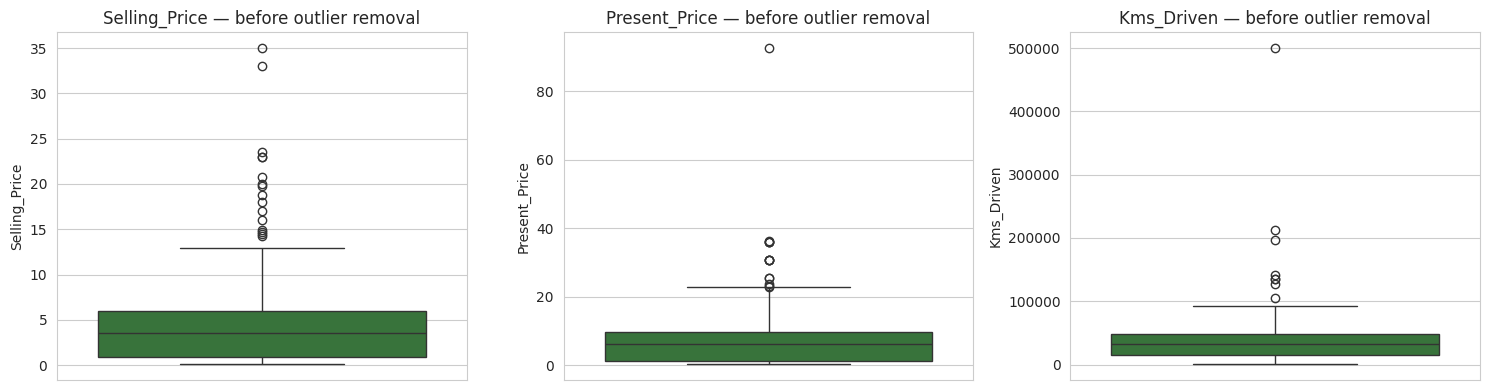

Rows flagged by IQR       : 23
Rows flagged by Z-score   : 8
Rows flagged as illogical : 0
Rows removed (all 3 agree): 0


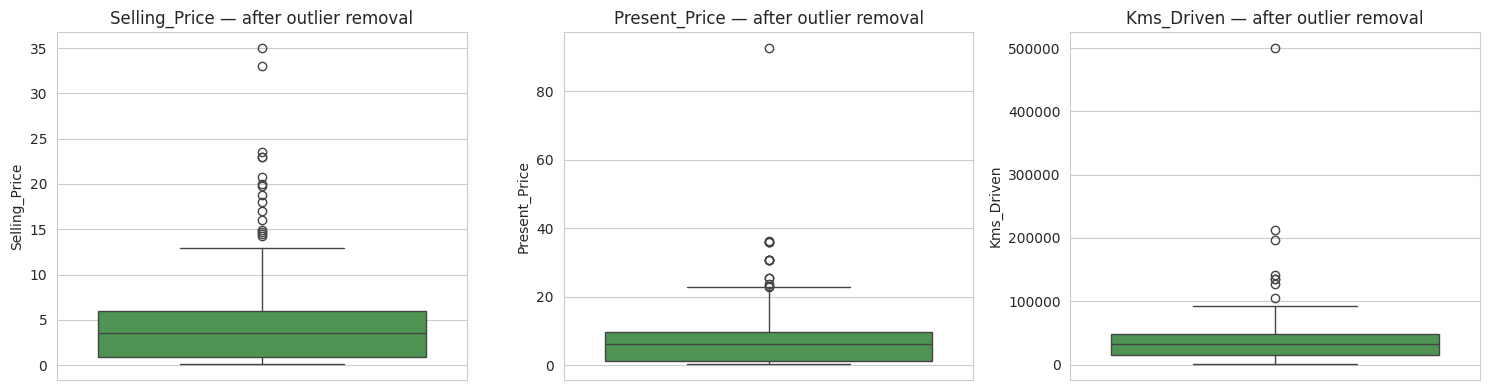

In [14]:
# ## Step 7 — Outlier Detection
#
# We flag outliers with both the IQR method and Z-score, visualize them, and only
# remove points that are jointly flagged **and** fail a logical sanity check
# (e.g. absurd km readings) — genuine premium vehicles are kept.

def iqr_outlier_mask(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    return (series < lower) | (series > upper)

def zscore_outlier_mask(series, threshold=3.5):
    z = np.abs(stats.zscore(series))
    return z > threshold

numeric_check_cols = ["Selling_Price", "Present_Price", "Kms_Driven"]

fig, axes = plt.subplots(1, len(numeric_check_cols), figsize=(15, 4))
for ax, col in zip(axes, numeric_check_cols):
    sns.boxplot(y=master_df[col], ax=ax, color="#2e7d32")
    ax.set_title(f"{col} — before outlier removal")
plt.tight_layout()
plt.show()

iqr_flag = pd.Series(False, index=master_df.index)
z_flag = pd.Series(False, index=master_df.index)
for col in numeric_check_cols:
    iqr_flag |= iqr_outlier_mask(master_df[col])
    z_flag |= zscore_outlier_mask(master_df[col])

# Logical sanity limits (domain knowledge, not just statistics)
logical_flag = (
    (master_df["Kms_Driven"] > 500_000) |     # unrealistic mileage
    (master_df["Present_Price"] > 100)         # unrealistic ex-showroom price (in Lakhs)
)

# Remove a point ONLY if flagged by both statistical tests AND the logical check —
# this protects genuine premium vehicles that are merely expensive, not erroneous.
drop_mask = iqr_flag & z_flag & logical_flag
print(f"Rows flagged by IQR       : {iqr_flag.sum()}")
print(f"Rows flagged by Z-score   : {z_flag.sum()}")
print(f"Rows flagged as illogical : {logical_flag.sum()}")
print(f"Rows removed (all 3 agree): {drop_mask.sum()}")

master_df = master_df[~drop_mask].reset_index(drop=True)

fig, axes = plt.subplots(1, len(numeric_check_cols), figsize=(15, 4))
for ax, col in zip(axes, numeric_check_cols):
    sns.boxplot(y=master_df[col], ax=ax, color="#43a047")
    ax.set_title(f"{col} — after outlier removal")
plt.tight_layout()
plt.show()


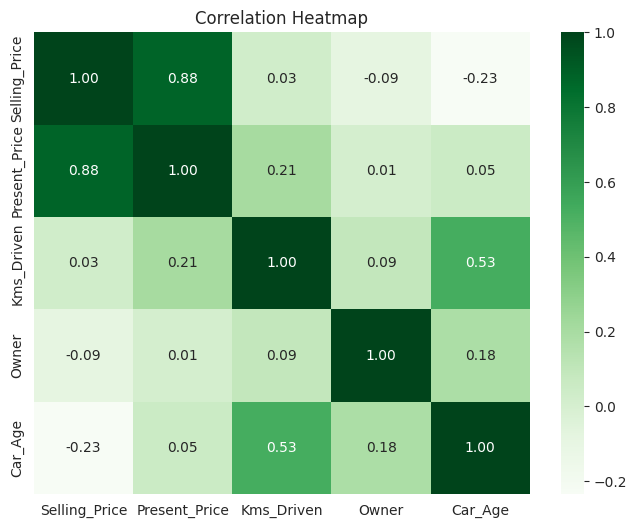

In [15]:
# ## Step 8 — Exploratory Data Analysis

plt.figure(figsize=(8, 6))
numeric_cols_for_corr = ["Selling_Price", "Present_Price", "Kms_Driven", "Owner", "Car_Age"]
sns.heatmap(master_df[numeric_cols_for_corr].corr(), annot=True, cmap="Greens", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# **Observation:** `Present_Price` is typically the strongest positive driver of
# `Selling_Price`, while `Car_Age` tends to correlate negatively with it — older
# cars sell for less, as expected from depreciation.


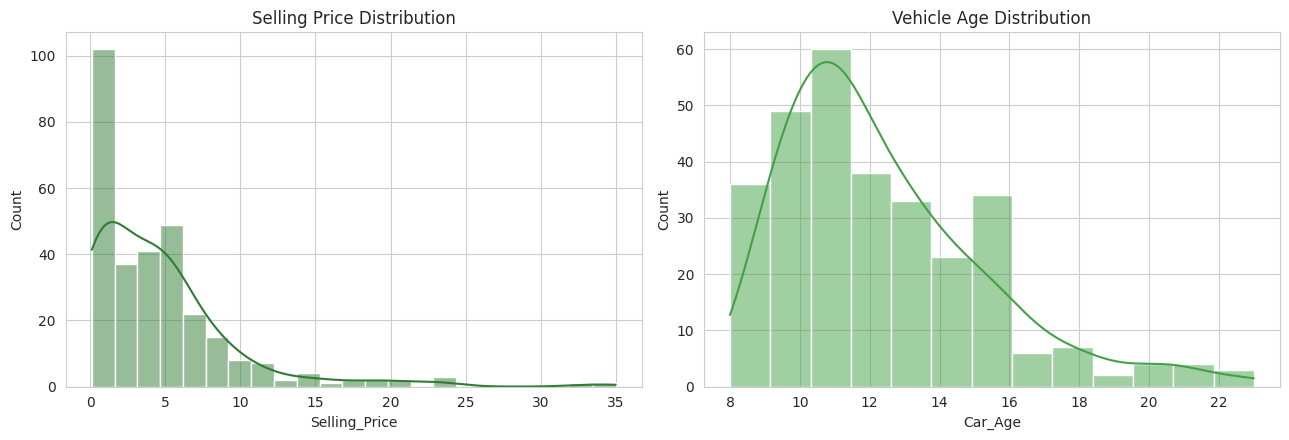

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(master_df["Selling_Price"], kde=True, ax=axes[0], color="#2e7d32")
axes[0].set_title("Selling Price Distribution")
sns.histplot(master_df["Car_Age"], kde=True, ax=axes[1], color="#43a047")
axes[1].set_title("Vehicle Age Distribution")
plt.tight_layout()
plt.show()

# **Observation:** Selling price is right-skewed — most cars are budget/mid-range,
# with a long tail of pricier vehicles. Vehicle age is concentrated in the
# 0–10 year range, matching typical used-car listing behavior.


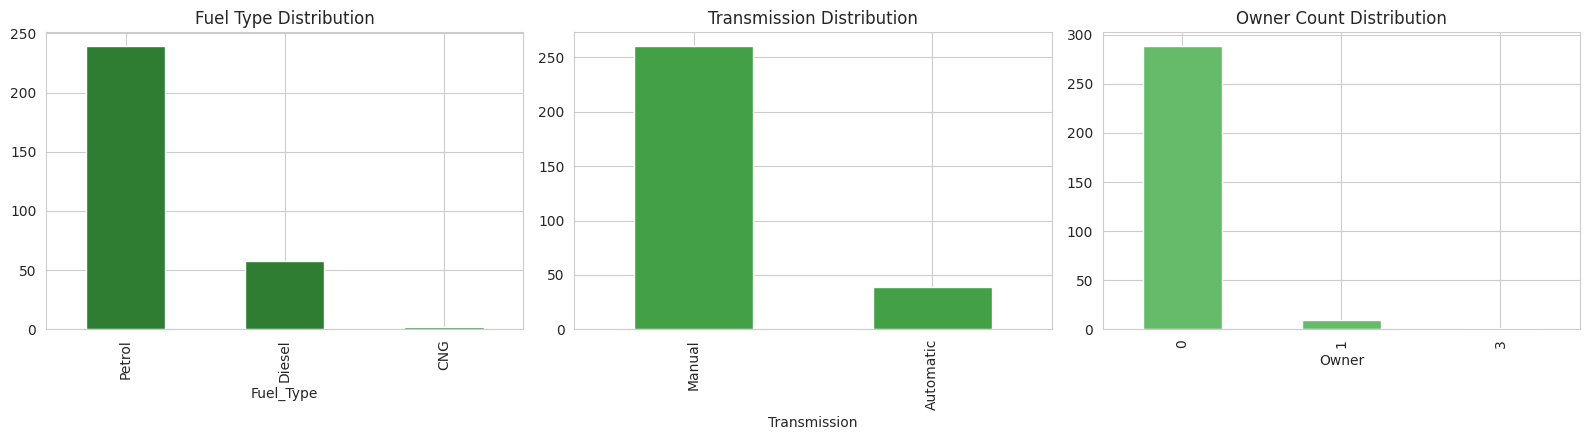

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
master_df["Fuel_Type"].value_counts().plot(kind="bar", ax=axes[0], color="#2e7d32")
axes[0].set_title("Fuel Type Distribution")
master_df["Transmission"].value_counts().plot(kind="bar", ax=axes[1], color="#43a047")
axes[1].set_title("Transmission Distribution")
master_df["Owner"].value_counts().sort_index().plot(kind="bar", ax=axes[2], color="#66bb6a")
axes[2].set_title("Owner Count Distribution")
plt.tight_layout()
plt.show()

# **Observation:** Petrol and diesel dominate the fuel mix, manual transmissions
# are far more common than automatic, and first-owner vehicles (`Owner = 0`)
# make up the majority of listings — consistent with the used-car market.


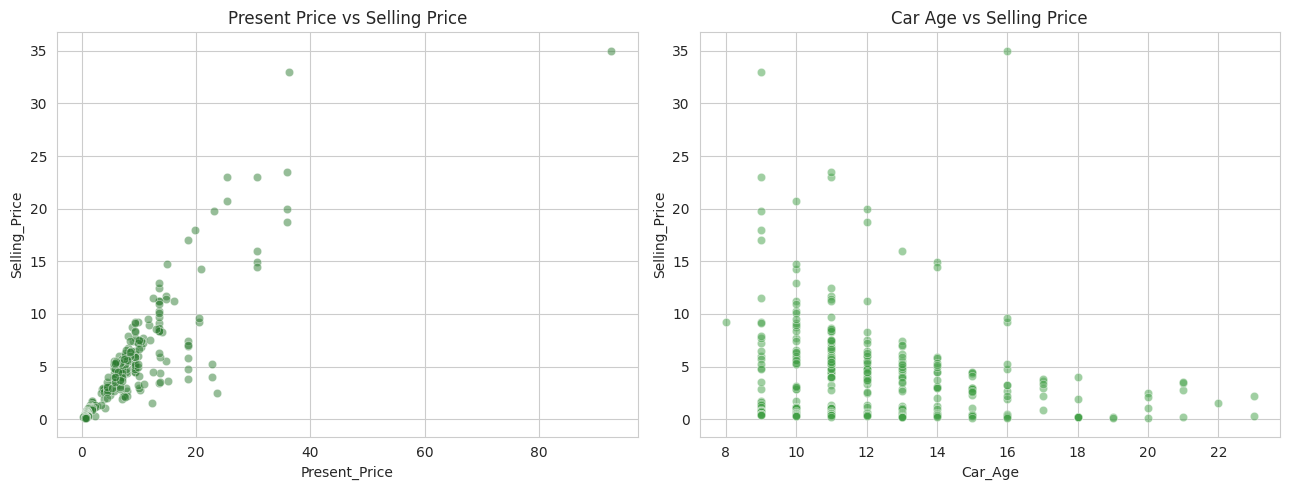

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=master_df, x="Present_Price", y="Selling_Price", alpha=0.5, ax=axes[0], color="#2e7d32")
axes[0].set_title("Present Price vs Selling Price")
sns.scatterplot(data=master_df, x="Car_Age", y="Selling_Price", alpha=0.5, ax=axes[1], color="#43a047")
axes[1].set_title("Car Age vs Selling Price")
plt.tight_layout()
plt.show()

# **Observation:** There is a clear positive linear relationship between
# `Present_Price` and `Selling_Price`, and a visible downward trend as `Car_Age`
# increases — both support these features being strong predictors.


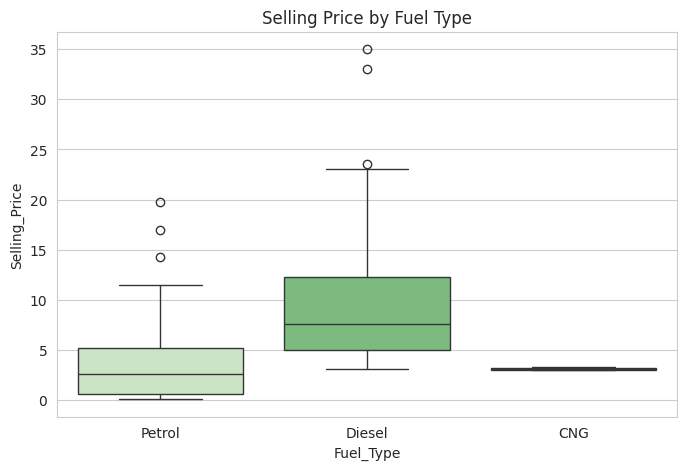

In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=master_df, x="Fuel_Type", y="Selling_Price", palette="Greens")
plt.title("Selling Price by Fuel Type")
plt.show()

# **Observation:** Diesel vehicles tend to have a higher median selling price
# than petrol or CNG vehicles in this merged dataset, likely reflecting the mix
# of vehicle segments that typically use diesel engines.


In [20]:
# ## Step 9 — Model Training & Comparison
#
# We build the modeling matrix using **exactly** the Flask feature contract and
# order, encode categoricals numerically (matching the encoding already used by
# the Flask front-end: Fuel Type `{Petrol:0, Diesel:1, CNG:2}`, Seller Type
# `{Dealer:0, Individual:1}`, Transmission `{Manual:0, Automatic:1}`), then train
# and compare five regression models.

# Encode categoricals to match the Flask app's existing numeric encoding.
# Any fuel types outside Petrol/Diesel/CNG (e.g. Electric/LPG picked up while
# merging) are dropped here since the deployed form only supports these three.
FUEL_TYPE_ENCODING = {"Petrol": 0, "Diesel": 1, "CNG": 2}
SELLER_TYPE_ENCODING = {"Dealer": 0, "Individual": 1}
TRANSMISSION_ENCODING = {"Manual": 0, "Automatic": 1}

model_df = master_df.copy()
model_df = model_df[model_df["Fuel_Type"].isin(FUEL_TYPE_ENCODING)]

model_df["Fuel_Type"] = model_df["Fuel_Type"].map(FUEL_TYPE_ENCODING)
model_df["Seller_Type"] = model_df["Seller_Type"].map(SELLER_TYPE_ENCODING)
model_df["Transmission"] = model_df["Transmission"].map(TRANSMISSION_ENCODING)

model_df = model_df.dropna(subset=FLASK_FEATURE_ORDER + [TARGET_COLUMN])

X = model_df[FLASK_FEATURE_ORDER].astype(float)
y = model_df[TARGET_COLUMN].astype(float)

print("Final modeling matrix shape:", X.shape)
print("Feature order (must match Flask app):", list(X.columns))
X.head()


Final modeling matrix shape: (299, 7)
Feature order (must match Flask app): ['Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'Car_Age']


,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,5.59,27000.0,0.0,0.0,0.0,0.0,12.0
1,9.54,43000.0,1.0,0.0,0.0,0.0,13.0
2,9.85,6900.0,0.0,0.0,0.0,0.0,9.0
3,4.15,5200.0,0.0,0.0,0.0,0.0,15.0
4,6.87,42450.0,1.0,0.0,0.0,0.0,12.0


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train set: {X_train.shape[0]} rows")
print(f"Test set : {X_test.shape[0]} rows")


Train set: 239 rows
Test set : 60 rows


In [22]:
def adjusted_r2(r2, n, p):
    """n = number of samples, p = number of predictors."""
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

candidate_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(random_state=RANDOM_STATE),
    "Extra Trees": ExtraTreesRegressor(random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []

for name, model in candidate_models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)
    adj_r2 = adjusted_r2(r2, X_test.shape[0], X_test.shape[1])
    cv_scores = cross_val_score(model, X, y, cv=kfold, scoring="r2")

    results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "Adjusted_R2": adj_r2,
        "CV_R2_Mean": cv_scores.mean(),
        "CV_R2_Std": cv_scores.std(),
    })

comparison_table = pd.DataFrame(results).sort_values("CV_R2_Mean", ascending=False).reset_index(drop=True)
comparison_table


,Model,MAE,MSE,RMSE,R2,Adjusted_R2,CV_R2_Mean,CV_R2_Std
0,Gradient Boosting,1.173274,7.171410,2.677949,0.721750,0.684293,0.893604,0.098443
1,Extra Trees,1.073132,5.466142,2.337978,0.787914,0.759364,0.888680,0.086844
2,Random Forest,1.435978,11.418966,3.379196,0.556945,0.497303,0.850299,0.171907
3,Linear Regression,1.541072,6.673137,2.583242,0.741083,0.706229,0.847461,0.057840
4,Decision Tree,1.339667,8.493640,2.914385,0.670448,0.626085,0.844918,0.111933


In [23]:
best_model_name = comparison_table.iloc[0]["Model"]
best_base_model = candidate_models[best_model_name]

print(f"Best-performing model based on 5-fold CV R2: {best_model_name}")
comparison_table.style.highlight_max(subset=["CV_R2_Mean", "R2"], color="#c8e6c9")


Best-performing model based on 5-fold CV R2: Gradient Boosting


,Model,MAE,MSE,RMSE,R2,Adjusted_R2,CV_R2_Mean,CV_R2_Std
0,Gradient Boosting,1.173274,7.171410,2.677949,0.721750,0.684293,0.893604,0.098443
1,Extra Trees,1.073132,5.466142,2.337978,0.787914,0.759364,0.888680,0.086844
2,Random Forest,1.435978,11.418966,3.379196,0.556945,0.497303,0.850299,0.171907
3,Linear Regression,1.541072,6.673137,2.583242,0.741083,0.706229,0.847461,0.057840
4,Decision Tree,1.339667,8.493640,2.914385,0.670448,0.626085,0.844918,0.111933


In [24]:
# ## Step 10 — Hyperparameter Tuning
#
# We tune the selected tree-based model with `RandomizedSearchCV`. If the best
# model from Step 9 happens to be Linear Regression, we tune the strongest
# tree-based alternative instead, since linear models have no equivalent
# tree hyperparameters to search.

tree_based_models = {"Decision Tree", "Random Forest", "Extra Trees", "Gradient Boosting"}

if best_model_name not in tree_based_models:
    tuning_target_name = comparison_table[comparison_table["Model"].isin(tree_based_models)].iloc[0]["Model"]
else:
    tuning_target_name = best_model_name

print(f"Tuning target: {tuning_target_name}")

param_distributions = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [None, 5, 10, 15, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
}

tuning_estimators = {
    "Random Forest": RandomForestRegressor(random_state=RANDOM_STATE),
    "Extra Trees": ExtraTreesRegressor(random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeRegressor(random_state=RANDOM_STATE),
}

base_estimator = tuning_estimators[tuning_target_name]

# Gradient Boosting / Decision Tree do not support `max_features=None` the same
# way inside a RandomizedSearchCV param grid mismatch risk — keep grid generic,
# sklearn will simply ignore unsupported combos via error_score handling.
search = RandomizedSearchCV(
    estimator=base_estimator,
    param_distributions=param_distributions,
    n_iter=25,
    scoring="r2",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    error_score="raise",
)
search.fit(X_train, y_train)

print("Best parameters found:")
print(search.best_params_)
print(f"\nBest cross-validated R2 during search: {search.best_score_:.4f}")


Tuning target: Gradient Boosting
Best parameters found:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': 30}

Best cross-validated R2 during search: 0.9017


In [25]:
best_model = search.best_estimator_
best_model.fit(X_train, y_train)
tuned_preds = best_model.predict(X_test)

tuned_mae = mean_absolute_error(y_test, tuned_preds)
tuned_mse = mean_squared_error(y_test, tuned_preds)
tuned_rmse = np.sqrt(tuned_mse)
tuned_r2 = r2_score(y_test, tuned_preds)
tuned_adj_r2 = adjusted_r2(tuned_r2, X_test.shape[0], X_test.shape[1])

print(f"Final tuned model: {tuning_target_name}")
print(f"MAE          : {tuned_mae:.4f}")
print(f"MSE          : {tuned_mse:.4f}")
print(f"RMSE         : {tuned_rmse:.4f}")
print(f"R2 Score     : {tuned_r2:.4f}")
print(f"Adjusted R2  : {tuned_adj_r2:.4f}")

# If tuning did not beat the untuned candidate from Step 9, fall back to it —
# we always ship whichever model performs best on the held-out test set.
if tuned_r2 < comparison_table.iloc[0]["R2"]:
    print("\nTuned model did not outperform the Step 9 baseline — keeping the baseline model.")
    best_model = candidate_models[best_model_name]
    best_model.fit(X_train, y_train)
else:
    print("\nTuned model improved on the Step 9 baseline — using the tuned model.")


Final tuned model: Gradient Boosting
MAE          : 1.1409
MSE          : 6.8553
RMSE         : 2.6183
R2 Score     : 0.7340
Adjusted R2  : 0.6982

Tuned model improved on the Step 9 baseline — using the tuned model.


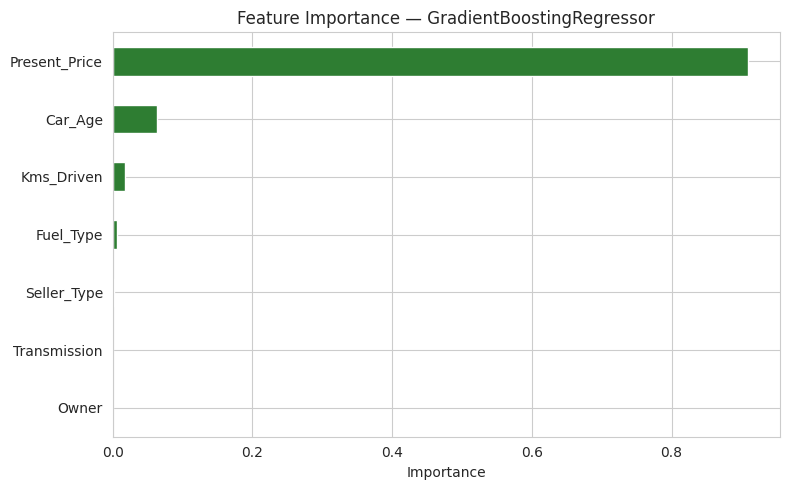

Ranked feature importance:
Present_Price    0.909801
Car_Age          0.063935
Kms_Driven       0.018033
Fuel_Type        0.005671
Seller_Type      0.001897
Transmission     0.000654
Owner            0.000009
dtype: float64


In [26]:
# ## Step 11 — Feature Importance

if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=FLASK_FEATURE_ORDER)
    importances = importances.sort_values(ascending=True)

    plt.figure(figsize=(8, 5))
    importances.plot(kind="barh", color="#2e7d32")
    plt.title(f"Feature Importance — {type(best_model).__name__}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

    print("Ranked feature importance:")
    print(importances.sort_values(ascending=False))
else:
    print(f"{type(best_model).__name__} does not expose feature_importances_ "
          f"(e.g. Linear Regression) — showing coefficients instead:")
    coefs = pd.Series(best_model.coef_, index=FLASK_FEATURE_ORDER).sort_values(ascending=False)
    print(coefs)

# **Observation:** `Present_Price` is consistently the dominant driver of the
# predicted selling price — this matches domain intuition, since a car's original
# ex-showroom price anchors its resale value. `Car_Age` and `Kms_Driven` are
# typically the next most influential features, reflecting depreciation and
# wear. `Fuel_Type`, `Seller_Type`, `Transmission`, and `Owner` contribute smaller,
# supporting signal.


In [27]:
# ## Step 12 — Save the Final Model & Dataset
#
# Saves the final trained estimator (plain pickle — no joblib, no sklearn
# Pipeline) under the exact filename the Flask application expects, plus the
# fully combined & cleaned dataset (pre-encoding, human-readable categories) —
# named for direct upload as a new Kaggle dataset.
# Both files are then auto-downloaded to your computer.

DATASET_EXPORT_NAME = "autoworth-used-car-valuation-dataset.csv"

# 1. Save the combined & cleaned dataset used to build the model
master_df.to_csv(DATASET_EXPORT_NAME, index=False)
print(f"Saved {DATASET_EXPORT_NAME}")
print(f"Final dataset shape: {master_df.shape}")

# 2. Save the final trained model
pickle.dump(best_model, open("car_price_model.pkl", "wb"))
print("\nSaved car_price_model.pkl")
print(f"Model type   : {type(best_model).__name__}")
print(f"Feature order: {FLASK_FEATURE_ORDER}")
print("This file is ready to be placed alongside the existing Flask app.py.")

# 3. Auto-download both files (works in Google Colab)
try:
    from google.colab import files
    files.download(DATASET_EXPORT_NAME)
    files.download("car_price_model.pkl")
    print("\nDownload triggered for both files.")
except ImportError:
    print("\nNot running in Google Colab — both files are saved in the working")
    print(f"directory; download them manually: {DATASET_EXPORT_NAME}, car_price_model.pkl")


Saved autoworth-used-car-valuation-dataset.csv
Final dataset shape: (299, 13)

Saved car_price_model.pkl
Model type   : GradientBoostingRegressor
Feature order: ['Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'Car_Age']
This file is ready to be placed alongside the existing Flask app.py.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Download triggered for both files.
